# Back Testing

Backtesting answers a more specific question than simply assessing model reliability. It asks: "If I had traded this strategy historically, what would my risk-adjusted returns have been?" It serves as a simulation of a trading strategy using historical data to estimate future performance. The key word is estimate—a backtest is never a guarantee, only a piece of evidence.

### Moving Average Crossover Strategy
The Moving Average (MA) crossover strategy dictates that we buy when a short-term MA crosses above a long-term MA, and sell when the short-term MA crosses below the long-term MA line. We will use a 20-day short MA and a 50-day long MA as our defaults. This configuration is fast enough to generate meaningful signals over three years of data, yet slow enough to avoid excessive noise.

### Performance Metrics

| Metric | Formula | Good Value |
| :--- | :--- | :--- |
| Sharpe ratio | $\frac{\bar{r} - r_f}{\sigma} \times \sqrt{252}$ | > 1.0 |
| Maximum drawdown | $\max\frac{\text{Peak} - \text{Trough}}{\text{Peak}}$ | < 20% |
| CAGR | $(1 + R_{\text{total}})^{252/N} - 1$ | > benchmark |
| Calmar ratio | CAGR / MDD | > 0.5 |
| Win rate | Fraction of profitable trades | > 50% |

### Alpha vs Returns
$$\alpha = R_{\text{strategy}} - R_{\text{benchmark}}$$

We will backtest our strategy against the benchmark of simply holding SPY for the entire period.

In [7]:
import yfinance as yf
import matplotlib.pyplot as plt 
import numpy as np
import sys
sys.path.insert(0, '..')  # so the notebook can find src/
from src.backtester import run_backtest

In [8]:
# fetch SPY prices
tk = yf.Ticker("SPY")
data = tk.history(period="3y")
prices = data['Close'].squeeze()

In [9]:
results = run_backtest(prices, rate=0.05, short_window=20, long_window=50)

In [10]:
print("Strategy Metrics:")
for k, v in results['strategy_metrics'].items():
    print(f"  {k}: {v:.4f}")

Strategy Metrics:
  CAGR: 0.1164
  WinRate: 0.5642
  SharpeRatio: 0.6112
  MDD: 0.0935
  CalmarRatio: 1.2450
  Alpha: -0.1175


In [11]:
print("\nBenchmark Metrics:")
for k, v in results['benchmark_metrics'].items():
    print(f"  {k}: {v:.4f}")


Benchmark Metrics:
  CAGR: 0.2339
  WinRate: 0.5752
  SharpeRatio: 1.0617
  MDD: 0.1876
  CalmarRatio: 1.2471
  Alpha: 0.0000


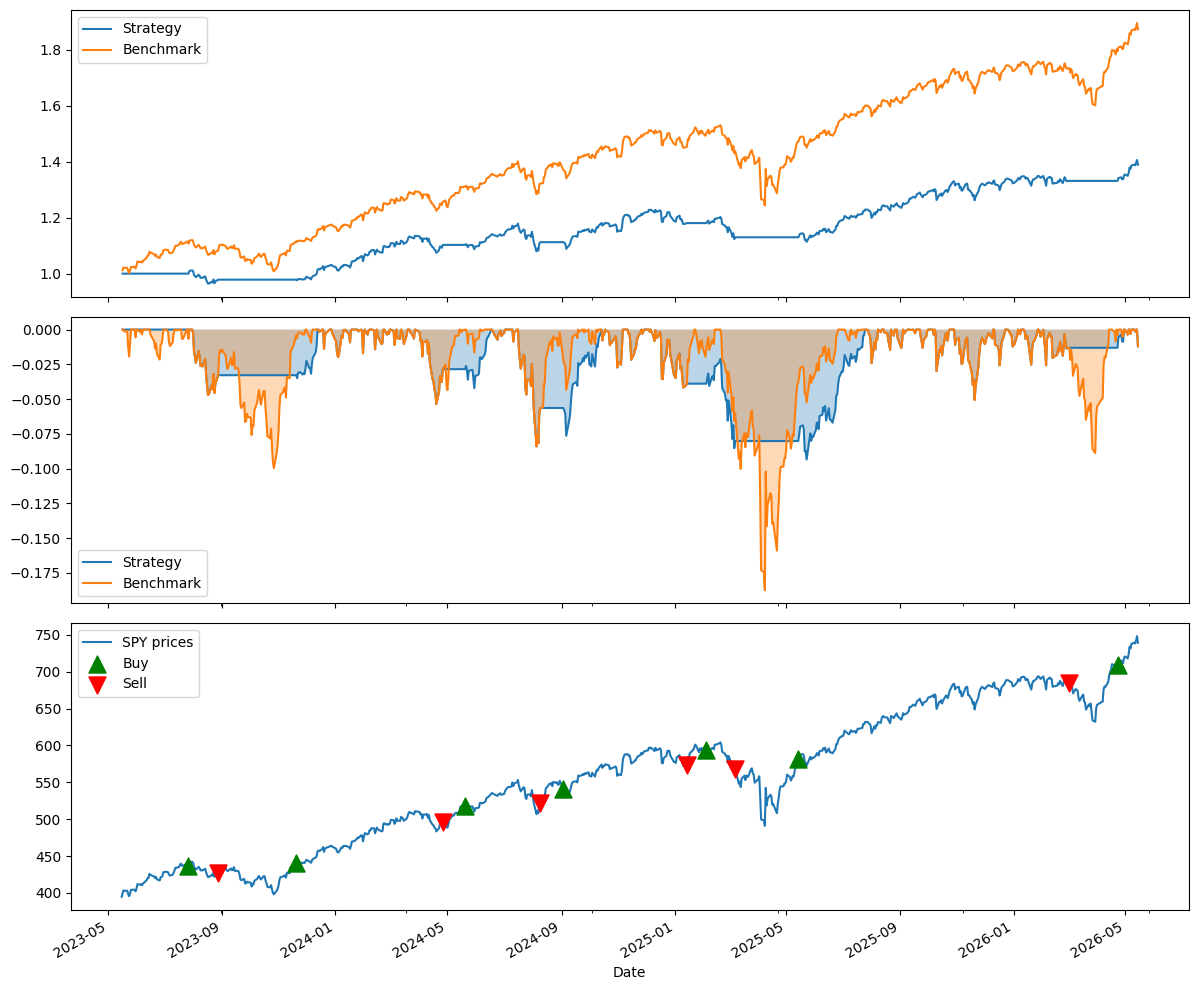

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
axes = axes.flatten()
strat_returns = results['strategy_returns']
bench_returns = results['benchmark_returns']
signals = results['signals']

# Plot 1 — Equity curves
strat_wealth = np.exp(np.cumsum(strat_returns / 100))
bench_wealth = np.exp(np.cumsum(bench_returns / 100))
# plot both on axes[0]
strat_wealth.plot(ax=axes[0], label='Strategy')
bench_wealth.plot(ax=axes[0], label='Benchmark')
axes[0].legend()

# Plot 2 — Drawdown
# compute drawdown series for both using the wealth index
# plot both on axes[1], fill below zero with fill_between

strat_peaks = np.maximum.accumulate(strat_wealth)
strat_drawdowns = (strat_wealth - strat_peaks) / strat_peaks

bench_peaks = np.maximum.accumulate(bench_wealth)
bench_drawdowns = (bench_wealth - bench_peaks) / bench_peaks

strat_drawdowns.plot(ax=axes[1], label='Strategy')
axes[1].fill_between(strat_drawdowns.index, strat_drawdowns.values, where=(strat_drawdowns<0), alpha=0.3)

bench_drawdowns.plot(ax=axes[1], label='Benchmark')
axes[1].fill_between(bench_drawdowns.index, bench_drawdowns.values, where=(bench_drawdowns<0), alpha=0.3)
axes[1].legend()

# Plot 3 — Price with signals
# plot prices on axes[2]
# overlay buy signals as green markers
# overlay sell signals as red markers
# hint: buy happens when signal changes from 0 to 1
#       sell happens when signal changes from 1 to 0

signal_changes = signals.diff()
buy_dates = signal_changes[signal_changes == 1].index
sell_dates = signal_changes[signal_changes == -1].index

prices.plot(ax=axes[2], label='SPY prices')
axes[2].scatter(buy_dates, prices[buy_dates], marker='^', color='green', s=150, zorder=5, label='Buy')
axes[2].scatter(sell_dates, prices[sell_dates], marker='v', color='red', s=150, zorder=5, label='Sell')
axes[2].legend()

plt.tight_layout()
plt.savefig("../results/05_backtesting.png", dpi=150)

**Plot 1 — Equity curves**

The benchmark (orange) reaches 1.80 — an 80% total return over 3 years. The strategy (blue) reaches only 1.35 — a 35% total return. The gap opens up significantly around early 2025 — the strategy exited during the crash and missed the recovery. You can see the blue line going flat (cash, no position) while the orange recovers.

**Plot 2 — Drawdown**

The strategy's worst drawdown is about -8% — much shallower than the benchmark's -19% spike in early 2025. But look at the duration — the strategy has persistent shallow drawdowns throughout, while the benchmark has sharp but brief ones. The strategy's drawdown protection comes at the cost of missing recoveries.

**Plot 3 — Signals**

Only about 8-10 trades over 3 years — very few. You can clearly see the problem: the sell signal near 2025-04 (red triangle) comes after the crash has already happened, and the buy signal (green triangle) comes after significant recovery has already occurred. The MA crossover is a lagging indicator by construction — it will always be late.